импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

загрузка данных

In [ ]:
dataset = pd.read_csv('NPHA-doctor-visits.csv')

размер датасета

In [ ]:
dataset.shape

(714, 15)

первые десять строк

In [ ]:
dataset.head(10)

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
5,2,2,3,2,4,3,0,0,0,1,0,3,3,1,1
6,3,2,4,1,1,3,0,0,1,1,0,2,1,1,1
7,2,2,3,2,6,3,1,0,0,0,0,3,3,1,1
8,2,2,3,1,2,3,0,0,1,1,0,3,3,1,2
9,1,2,2,1,3,1,0,0,0,0,1,3,3,1,1


и еще библиотеки

In [ ]:
import mpl_toolkits.mplot3d
from sklearn import datasets
from sklearn.cluster import KMeans

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Number of Doctors Visited                   714 non-null    int64
 1   Age                                         714 non-null    int64
 2   Phyiscal Health                             714 non-null    int64
 3   Mental Health                               714 non-null    int64
 4   Dental Health                               714 non-null    int64
 5   Employment                                  714 non-null    int64
 6   Stress Keeps Patient from Sleeping          714 non-null    int64
 7   Medication Keeps Patient from Sleeping      714 non-null    int64
 8   Pain Keeps Patient from Sleeping            714 non-null    int64
 9   Bathroom Needs Keeps Patient from Sleeping  714 non-null    int64
 10  Uknown Keeps Patient from Sleeping    

In [ ]:
dataset.describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714.000000,714.0,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.00000
mean,2.112045,2.0,2.794118,1.988796,3.009804,2.806723,0.247899,0.056022,0.218487,0.504202,0.417367,2.407563,2.829132,1.425770,1.55042
std,0.683441,0.0,0.900939,0.939928,1.361117,0.586582,0.432096,0.230126,0.413510,0.500333,0.493470,0.670349,0.546767,1.003896,0.49780
min,1.000000,2.0,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,1.00000
25%,2.000000,2.0,2.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.00000
50%,2.000000,2.0,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,1.000000,2.00000
75%,3.000000,2.0,3.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.00000
max,3.000000,2.0,5.000000,5.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,5.000000,2.00000


считаем количество людей в каждой группе по полу

In [70]:
dataset['Gender'].value_counts()

,count
Gender,
2,393
1,321


группы примерно равны

визуализация

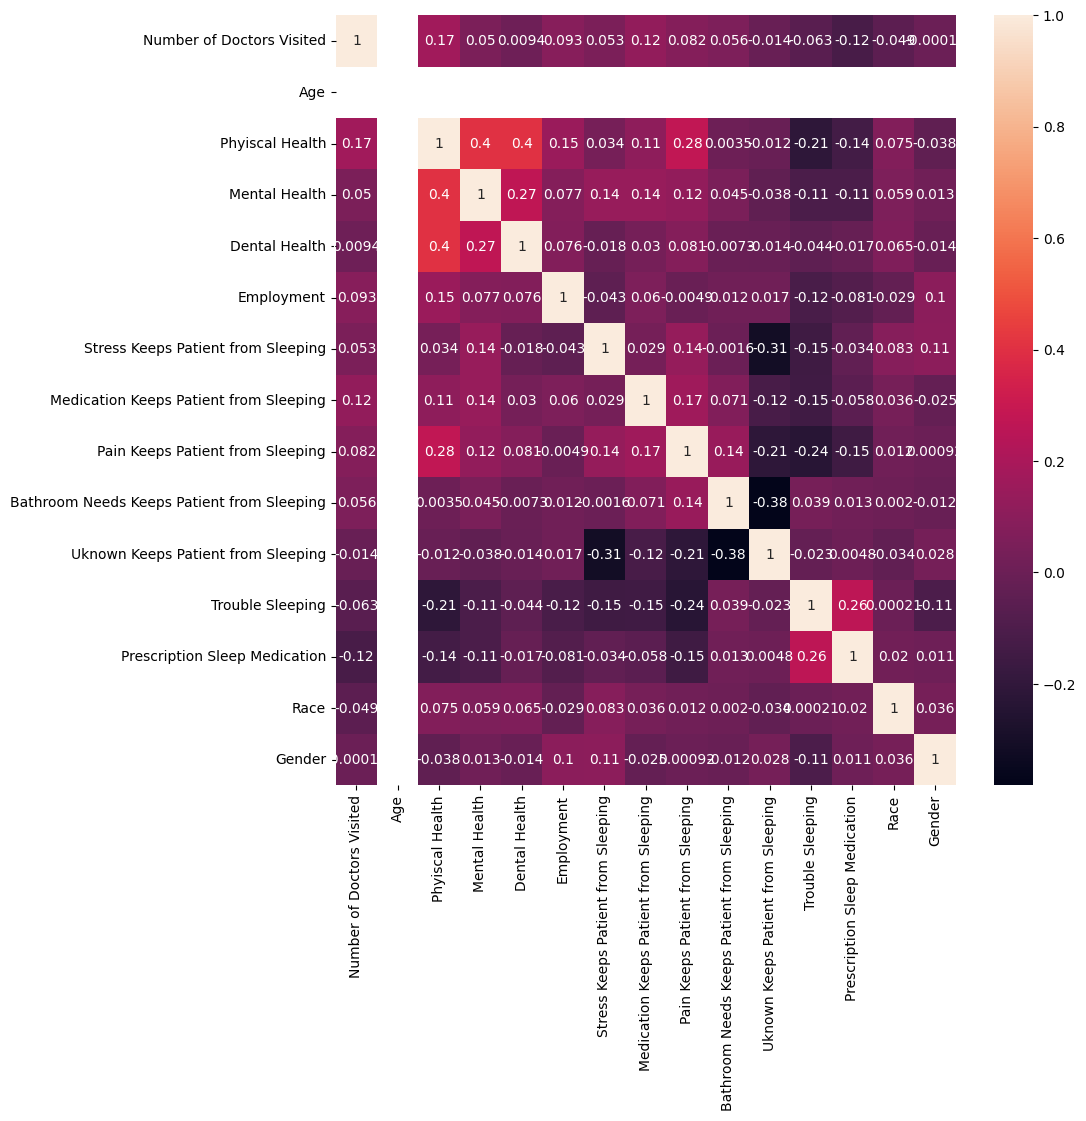

In [71]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset.corr(numeric_only = True), annot=True)
plt.show()

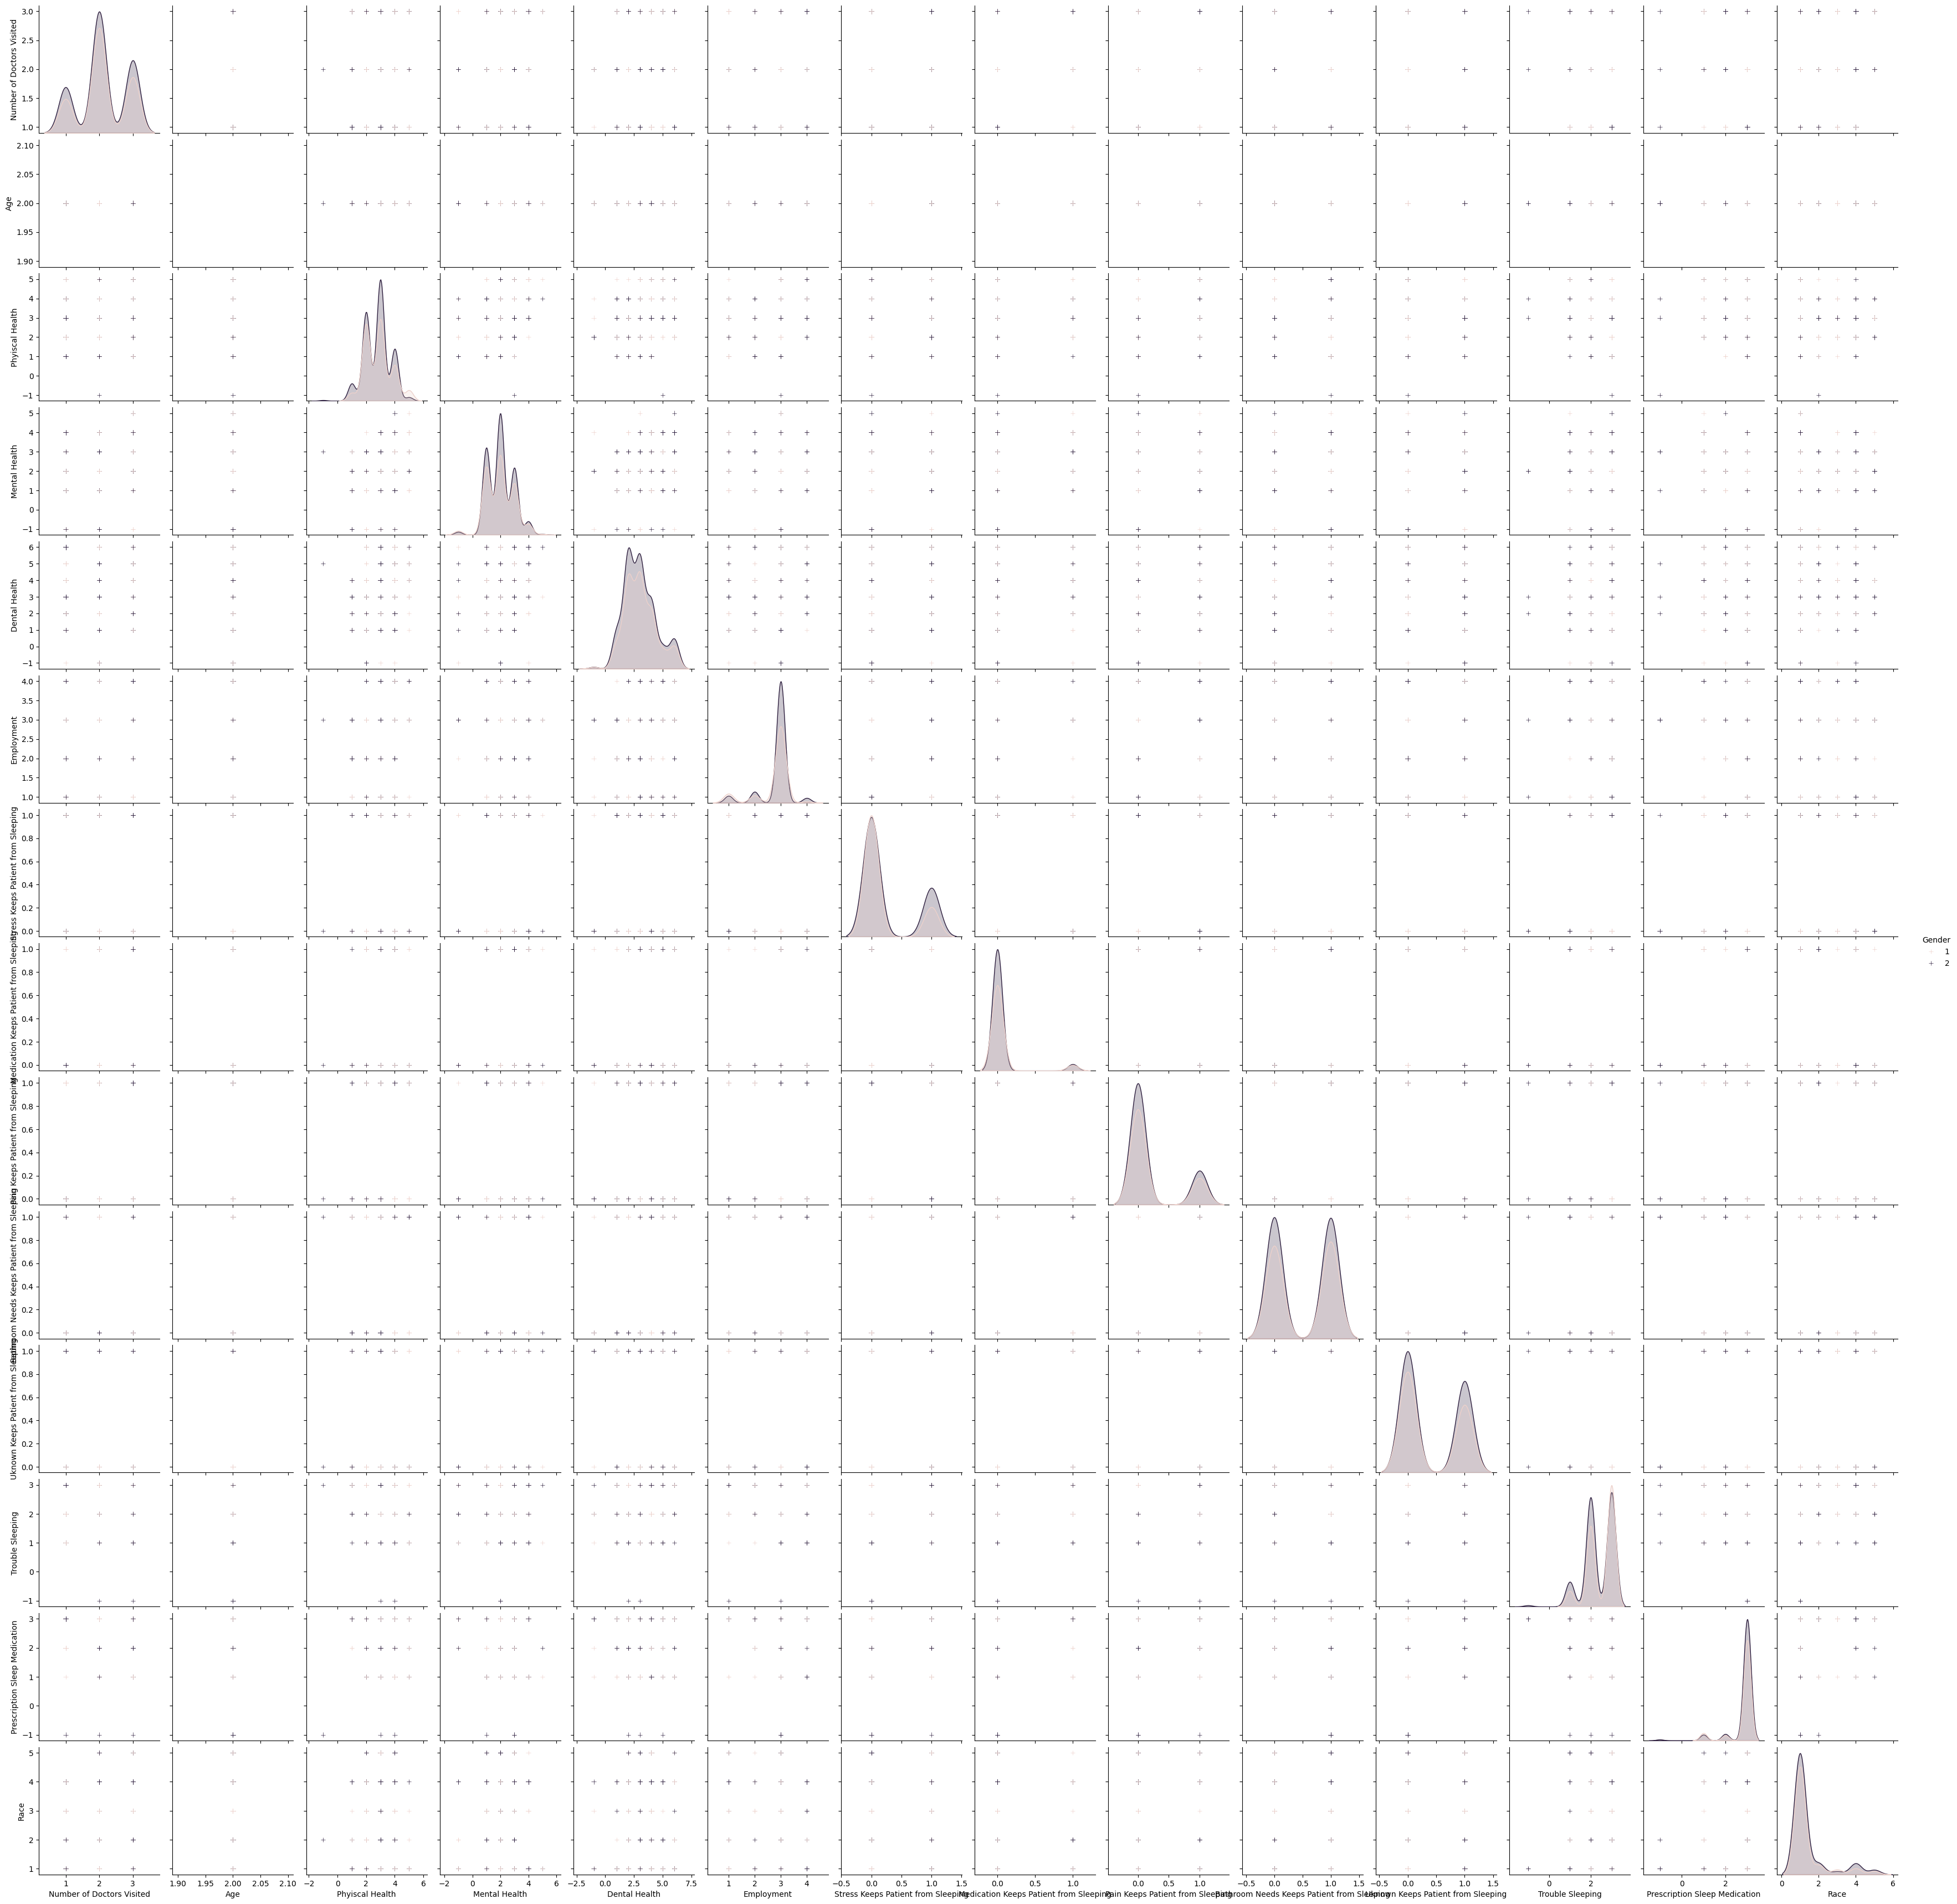

In [72]:
sns.pairplot(dataset, hue='Gender', markers='+')
plt.show()

разделим данные на обучающую и тестовую выборки

In [73]:
X = dataset.drop(['Gender'], axis=1)
y = dataset['Gender']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (714, 14) | y shape: (714,) 


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
train_distribution = y_train.value_counts(normalize=True).sort_index() * 100
test_distribution = y_test.value_counts(normalize=True).sort_index() * 100
comparison_df = pd.DataFrame({'Train (%)': train_distribution, 'Test (%)': test_distribution})
print(comparison_df)

        Train (%)   Test (%)
Gender                      
1       45.008757  44.755245
2       54.991243  55.244755


перейдем к обучению и выбору оптимальной модели

In [78]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

In [79]:
sk_lda = LinearDiscriminantAnalysis(solver='svd')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.5594405594405595
sk LDA prediction: [1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 1 2 2 2 2 1 1 1 2 2 2 2 2 2 2 2 2 1
 1 2 1 2 2 2 2 1 2 2 1 2 1 2 2 1 2 2 1 2 2 2 1 2 2 1 2 2 2 1 2 2 2 1 2 1 2
 1 2 2 1 2 2 1 1 2 2 2 2 2 2 2 2 1 2 2 2 1 2 1 2 2 1 2 1 1 2 1 2 1 1 2 2 1
 2 1 2 2 2 2 1 1 2 1 2 1 2 2 2 2 2 2 1 2 1 2 1 2 1 1 2 2 1 1 1 2]
sk transformed features
[[-0.10004539  0.5121039   0.33620344 -2.06668347 -0.94097932]]


Accuracy 56% - в принципе неплохо

In [80]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
predicted = sk_lda.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.56
Precision (confidence when predicting a 1): 0.55
Detail:
              precision    recall  f1-score   support

           1       0.51      0.38      0.43        64
           2       0.58      0.71      0.64        79

    accuracy                           0.56       143
   macro avg       0.55      0.54      0.54       143
weighted avg       0.55      0.56      0.55       143



In [81]:
sk_lr = LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial')
sk_lr.fit(X_train, y_train)
sk_lr_pred = sk_lr.predict(X_test)
sk_lr_accuracy = accuracy_score(y_test, sk_lr_pred)
print(f"accuracy: {sk_lr_accuracy}")
print(f"prediction: {sk_lr_pred}")

accuracy: 0.5594405594405595
prediction: [1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 1 2 2 2 2 1 1 1 2 2 2 2 2 2 2 2 2 1
 1 2 1 2 2 2 2 1 2 2 1 2 1 2 2 1 2 2 1 2 2 2 1 2 2 1 2 2 2 1 2 2 2 1 2 1 2
 1 2 2 1 2 2 1 1 2 2 2 2 2 2 2 2 1 2 2 2 1 2 1 2 2 1 2 1 1 2 1 2 1 1 2 2 1
 2 1 2 2 2 2 1 1 2 1 2 1 2 2 2 2 2 2 1 2 1 2 1 2 1 1 2 2 1 1 1 2]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [83]:
predicted = sk_lr.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.56
Precision (confidence when predicting a 1): 0.55
Detail:
              precision    recall  f1-score   support

           1       0.51      0.38      0.43        64
           2       0.58      0.71      0.64        79

    accuracy                           0.56       143
   macro avg       0.55      0.54      0.54       143
weighted avg       0.55      0.56      0.55       143



In [92]:
for k in [3, 4, 5, 6, 7, 8, 9, 60]:
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train, y_train)
    sk_knn_pred = sk_knn.predict(X_test)
    sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred)
    print(f"KNN (k={k}) accuracy: {sk_knn_accuracy}")

KNN (k=3) accuracy: 0.5034965034965035
KNN (k=4) accuracy: 0.4405594405594406
KNN (k=5) accuracy: 0.5244755244755245
KNN (k=6) accuracy: 0.5104895104895105
KNN (k=7) accuracy: 0.5104895104895105
KNN (k=8) accuracy: 0.46153846153846156
KNN (k=9) accuracy: 0.5174825174825175
KNN (k=60) accuracy: 0.5524475524475524


In [93]:
sk_knn = KNeighborsClassifier(n_neighbors=60)
sk_knn.fit(X_train, y_train)
sk_knn_pred = sk_knn.predict(X_test)
sk_knn_accuracy = accuracy_score(y_test, sk_knn_pred)
print(f"\nИтоговый KNN (k=60) accuracy: {sk_knn_accuracy}")


Итоговый KNN (k=60) accuracy: 0.5524475524475524


In [94]:
predicted = sk_knn.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.55
Precision (confidence when predicting a 1): 0.54
Detail:
              precision    recall  f1-score   support

           1       0.50      0.38      0.43        64
           2       0.58      0.70      0.63        79

    accuracy                           0.55       143
   macro avg       0.54      0.54      0.53       143
weighted avg       0.54      0.55      0.54       143



стало чуть хуже,  результат похож на первые модели только при большом количестве соседей

In [102]:
sk_tree = DecisionTreeClassifier(random_state=60)
sk_tree.fit(X_train, y_train)
sk_tree_pred = sk_tree.predict(X_test)
sk_tree_accuracy = accuracy_score(y_test, sk_tree_pred)
print(f"accuracy: {sk_tree_accuracy}")

accuracy: 0.5384615384615384


In [103]:
predicted = sk_tree.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.54
Precision (confidence when predicting a 1): 0.54
Detail:
              precision    recall  f1-score   support

           1       0.48      0.50      0.49        64
           2       0.58      0.57      0.58        79

    accuracy                           0.54       143
   macro avg       0.53      0.53      0.53       143
weighted avg       0.54      0.54      0.54       143



модели получают процентик выше 50, уже хоть что-то

In [104]:
sk_svc = SVC(gamma='auto', decision_function_shape='ovo')
sk_svc.fit(X_train, y_train)
sk_svc_pred = sk_svc.predict(X_test)
sk_svc_accuracy = accuracy_score(y_test, sk_svc_pred)
print(f"accuracy: {sk_svc_accuracy}")

accuracy: 0.5944055944055944


векторы лучше всего себя показали

In [105]:
predicted = sk_svc.predict(X_test)
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")
f1 = metrics.f1_score(y_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.59
Precision (confidence when predicting a 1): 0.59
Detail:
              precision    recall  f1-score   support

           1       0.58      0.34      0.43        64
           2       0.60      0.80      0.68        79

    accuracy                           0.59       143
   macro avg       0.59      0.57      0.56       143
weighted avg       0.59      0.59      0.57       143



процентик получился почти 60%, модель хорошо справляется с опознаванием класса 2, но плохо распознает 1. приемлемо